# 02 — Exploração: existe sinal nas notícias?

**Pergunta:** ao transformar notícias não estruturadas em scores, aparece alguma relação visível com o mercado?

O objetivo aqui não é provar causalidade. Procuramos um **indício visual** que justifique o teste fora da amostra nos notebooks seguintes.


In [60]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)

plt.style.use('seaborn-v0_8-whitegrid')
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
NEWS_PATH = PROJECT_ROOT / 'data/processed/energy_br.csv'
MARKET_PATH = PROJECT_ROOT / 'data/market/energy_market_daily.csv'
OUTPUT_PATH = PROJECT_ROOT / 'data/features/energy_market_news_daily.csv'

In [ ]:
news = pd.read_csv(NEWS_PATH)
market = pd.read_csv(MARKET_PATH)
news['published_at'] = pd.to_datetime(news['published_at'], utc=True, errors='coerce')
news['score'] = pd.to_numeric(news['score'], errors='coerce')
news['relevance'] = pd.to_numeric(news['relevance'], errors='coerce')
news['sentiment'] = news['sentiment'].astype(str).str.lower()
news = news.dropna(subset=['published_at', 'score', 'relevance']).copy()
market['date'] = pd.to_datetime(market.pop('dia'), errors='coerce')
market = market.dropna(subset=['date', 'preco_fecho']).sort_values('date').reset_index(drop=True)
print(f'Notícias analisadas: {len(news):,}')
print(f'dias de negociação: {len(market):,} | {market.date.min().date()} → {market.date.max().date()}')

Notícias analisadas: 2,352
dias de operaçãoões: 159 | 2026-01-02 → 2026-08-24


## 1. De texto a número

A IA classifica direção e relevância de cada notícia. Depois, esses scores são condensados em um sinal diário entre −1 e +1.


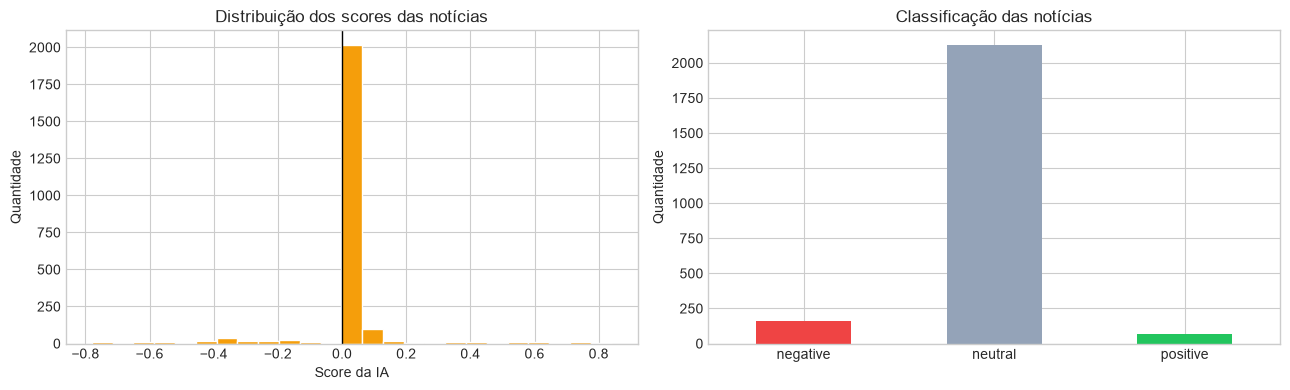

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(news['score'], bins=25, color='#f59e0b', edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set(title='Distribuição dos scores das notícias', xlabel='Score da IA', ylabel='Quantidade')
sentiment_counts = news['sentiment'].value_counts().reindex(['negative', 'neutral', 'positive'], fill_value=0)
sentiment_counts.plot.bar(ax=axes[1], color=['#ef4444', '#94a3b8', '#22c55e'], rot=0)
axes[1].set(title='Classificação das notícias', xlabel='', ylabel='Quantidade')
plt.tight_layout(); plt.show()

## 2. Alinhamento temporal
Cada notícia é atribuída ao primeiro dias de negociação na sua data ou depois dela. Assim, notícias de sábado e domingo entram no sinal de segunda-feira. O sinal conhecido ao fim do dias de negociação **t** será usado somente para prever **t+1**.

In [ ]:
# Normaliza a data da notícia para o dia do calendário, removendo hora e fuso.
calendar_news = news.assign(news_date=news['published_at'].dt.tz_convert(None).dt.normalize()).sort_values('news_date')
# Mantém apenas datas de dias de negociação e prepara a coluna usada no alinhamento.
trading_dates = market[['date']].rename(columns={'date': 'signal_date'}).sort_values('signal_date')
# Atribui cada notícia ao primeiro dias de negociação na data da notícia ou depois dela. notícias no fim de semana são associadas  segunda
aligned = pd.merge_asof(calendar_news, trading_dates, left_on='news_date', right_on='signal_date', direction='forward')
aligned = aligned.dropna(subset=['signal_date']).copy()

# Combina direção e relevância: notícias relevantes têm maior peso no sinal.
aligned['weighted_score'] = aligned['score'] * aligned['relevance']
aligned['is_positive'] = (aligned['sentiment'] == 'positive').astype(int)
aligned['is_neutral'] = (aligned['sentiment'] == 'neutral').astype(int)
aligned['is_negative'] = (aligned['sentiment'] == 'negative').astype(int)

# Resume as notícias por dias de negociação para transformar dados individuais em features diárias.
daily_news = aligned.groupby('signal_date').agg(
    news_count=('score', 'size'), weighted_sum=('weighted_score', 'sum'),
# O sinal diário será weighted_sum / total_relevance.
    total_relevance=('relevance', 'sum'), avg_score=('score', 'mean'),
    avg_relevance=('relevance', 'mean'), positive_count=('is_positive', 'sum'),
    neutral_count=('is_neutral', 'sum'), negative_count=('is_negative', 'sum'),
).reset_index().rename(columns={'signal_date': 'date'})
daily_news['signal'] = daily_news['weighted_sum'] / daily_news['total_relevance']

# Calcula a participação de cada classe de sentimento no total diário.
for label in ['positive', 'neutral', 'negative']:
    daily_news[f'{label}_share'] = daily_news[f'{label}_count'] / daily_news['news_count']

# Sinal menos ruidoso: considera somente notícias com relevância igual ou superior a 0.70.
high_relevance = aligned.query('relevance >= 0.70').copy()
high_daily = high_relevance.groupby('signal_date').agg(
    high_weighted_sum=('weighted_score', 'sum'),
    high_total_relevance=('relevance', 'sum'),
    high_relevance_news_count=('score', 'size'),
).reset_index().rename(columns={'signal_date': 'date'})
high_daily['high_relevance_signal'] = high_daily['high_weighted_sum'] / high_daily['high_total_relevance']
daily_news = daily_news.merge(high_daily, on='date', how='left', validate='one_to_one')

# Sinal ainda mais seletivo, usado no SARIMAX, para eventos potencialmente materiais.
very_high_relevance = aligned.query('relevance >= 0.85').copy()
very_high_daily = very_high_relevance.groupby('signal_date').agg(
    very_high_weighted_sum=('weighted_score', 'sum'),
    very_high_total_relevance=('relevance', 'sum'),
    very_high_relevance_news_count=('score', 'size'),
).reset_index().rename(columns={'signal_date': 'date'})
very_high_daily['very_high_relevance_signal'] = very_high_daily['very_high_weighted_sum'] / very_high_daily['very_high_total_relevance']
daily_news = daily_news.merge(very_high_daily, on='date', how='left', validate='one_to_one')

# Inspeciona as colunas principais geradas para a análise e os notebooks de modelagem.
daily_news[['date', 'news_count', 'signal', 'high_relevance_signal', 'very_high_relevance_signal', 'negative_share']].head()

,date,news_count,signal,high_relevance_signal,very_high_relevance_signal,negative_share
0,2026-01-05,14,-0.100602,NaN,NaN,0.142857
1,2026-01-06,13,-0.068132,NaN,NaN,0.076923
2,2026-01-07,14,0.030000,NaN,NaN,0.000000
3,2026-01-08,12,0.107159,NaN,NaN,0.000000
4,2026-01-09,12,0.028082,NaN,NaN,0.000000


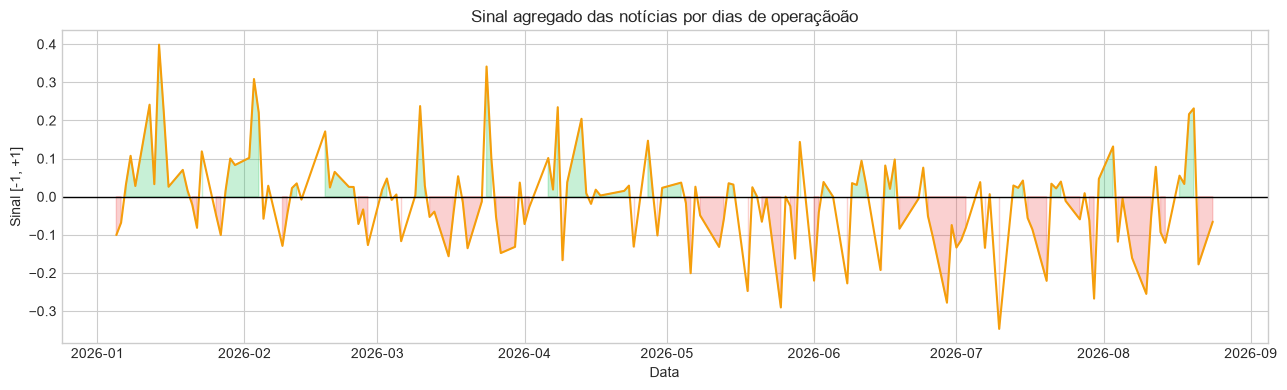

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily_news['date'], daily_news['signal'], color='#f59e0b', linewidth=1.5)
ax.axhline(0, color='black', linewidth=1)
ax.fill_between(daily_news['date'], 0, daily_news['signal'], where=daily_news['signal'] >= 0, color='#22c55e', alpha=.25)
ax.fill_between(daily_news['date'], 0, daily_news['signal'], where=daily_news['signal'] < 0, color='#ef4444', alpha=.25)
ax.set(title='Sinal agregado das notícias por ddias de negociação', xlabel='Data', ylabel='Sinal [-1, +1]')
plt.tight_layout(); plt.show()

## 3. O indício visual

Primeiro vemos a relação diária, naturalmente ruidosa. Depois usamos médias móveis de 20 dias de negociação para revelar movimentos persistentes de preço e notícias em uma escala comparável.


In [65]:
df = market.merge(daily_news, on='date', how='left', validate='one_to_one')
zero_columns = ['news_count', 'weighted_sum', 'total_relevance', 'avg_score', 'avg_relevance', 'positive_count', 'neutral_count', 'negative_count', 'signal', 'positive_share', 'neutral_share', 'negative_share', 'high_weighted_sum', 'high_total_relevance', 'high_relevance_news_count', 'high_relevance_signal', 'very_high_weighted_sum', 'very_high_total_relevance', 'very_high_relevance_news_count', 'very_high_relevance_signal']
df[zero_columns] = df[zero_columns].fillna(0.0)
df['high_relevance_signal_ma_2'] = df['high_relevance_signal'].rolling(2, min_periods=1).mean()
df['very_high_relevance_signal_ma_7'] = df['very_high_relevance_signal'].rolling(7, min_periods=1).mean()
df['return'] = df['preco_fecho'].pct_change()
df['intraday_range'] = df['preco_max'] - df['preco_min']
df['return_next_day'] = df['return'].shift(-1)
df['direction_next_day'] = np.where(df['return_next_day'].notna(), (df['return_next_day'] > 0).astype(int), np.nan)
df['close_next_day'] = df['preco_fecho'].shift(-1)

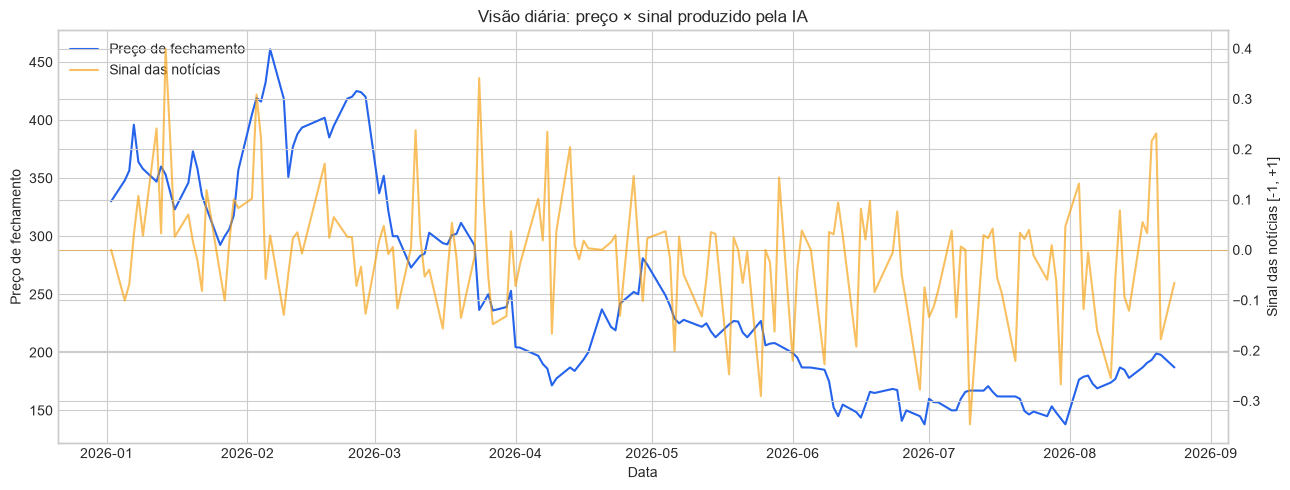

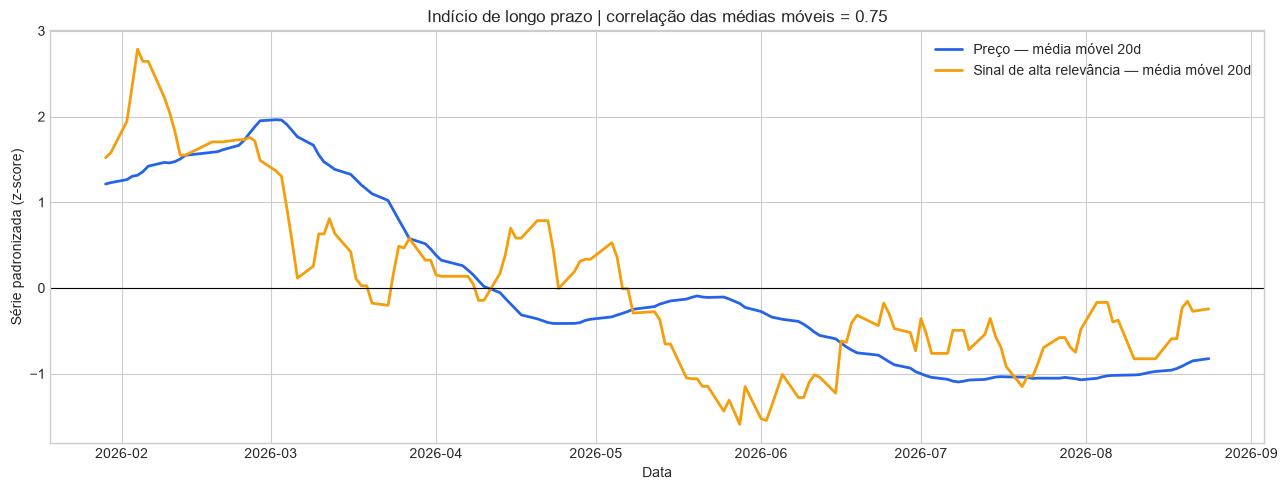

Correlação entre as médias móveis de 20 dias de negociação: 0.752
Associação visual não implica causalidade; a validação preditiva é feita nos notebooks seguintes.


In [ ]:
fig, ax_price = plt.subplots(figsize=(13, 5))
ax_price.plot(df['date'], df['preco_fecho'], color='#2563eb', label='Preço de fechamento')
ax_price.set(xlabel='Data', ylabel='Preço de fechamento')
ax_signal = ax_price.twinx()
ax_signal.plot(df['date'], df['signal'], color='#f59e0b', alpha=.65, label='Sinal das notícias')
ax_signal.axhline(0, color='#f59e0b', linewidth=.7, alpha=.5)
ax_signal.set_ylabel('Sinal das notícias [-1, +1]')
lines = ax_price.get_lines() + ax_signal.get_lines()[:1]
ax_price.legend(lines, [line.get_label() for line in lines], loc='upper left')
ax_price.set_title('Visão diária: preço × sinal produzido pela IA')
plt.tight_layout(); plt.show()

# A série diária é ruidosa. Médias móveis de 20 dias de negociação destacam a relação de longo prazo.
LONG_WINDOW = 20
price_long = df['preco_fecho'].rolling(LONG_WINDOW).mean()
news_long = df['high_relevance_signal'].rolling(LONG_WINDOW).mean()
price_long_z = (price_long - price_long.mean()) / price_long.std()
news_long_z = (news_long - news_long.mean()) / news_long.std()
long_term_correlation = price_long.corr(news_long)
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['date'], price_long_z, color='#2563eb', linewidth=2, label='Preço — média móvel 20d')
ax.plot(df['date'], news_long_z, color='#f59e0b', linewidth=2, label='Sinal de alta relevância — média móvel 20d')
ax.axhline(0, color='black', linewidth=.8)
ax.set(title=f'Indício de longo prazo | correlação das médias móveis = {long_term_correlation:.2f}', xlabel='Data', ylabel='Série padronizada (z-score)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Correlação entre as médias móveis de {LONG_WINDOW} dias de negociação: {long_term_correlation:.3f}')
print('Associação visual não implica causalidade; a validação preditiva é feita nos notebooks seguintes.')


## Conclusão da exploração

As médias móveis apresentam associação visual positiva. Isso é um **indício, não uma prova**: tendências comuns podem produzir correlação. O **próximo passo é verificar se a notícia melhora** o resultado fora da amostra, mantendo o mesmo modelo e alterando apenas o conjunto de features.

## 4. Dataset de modelagem


In [ ]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)
#print(f'✓ {len(df):,} dias de negociação salvos em {OUTPUT_PATH}')
df.tail()

,preco_max,preco_min,preco_fecho,quantidade_total,total_ordens_dia,date,news_count,weighted_sum,total_relevance,avg_score,avg_relevance,positive_count,neutral_count,negative_count,signal,positive_share,neutral_share,negative_share,high_weighted_sum,high_total_relevance,high_relevance_news_count,high_relevance_signal,very_high_weighted_sum,very_high_total_relevance,very_high_relevance_news_count,very_high_relevance_signal,high_relevance_signal_ma_2,very_high_relevance_signal_ma_7,return,intraday_range,return_next_day,direction_next_day,close_next_day
154,191.0,185.0,190.99,29,24,2026-08-18,11.0,0.0380,1.14,0.018182,0.103636,0.0,11.0,0.0,0.033333,0.000000,1.000000,0.000000,0.0000,0.00,0.0,0.000000,0.0000,0.00,0.0,0.000000,0.000000,-0.088571,0.021337,6.0,0.013142,1.0,193.5
155,193.5,185.0,193.50,24,21,2026-08-19,13.0,0.5974,2.76,0.048462,0.212308,1.0,11.0,1.0,0.216449,0.076923,0.846154,0.076923,0.6532,0.92,1.0,0.710000,0.6532,0.92,1.0,0.710000,0.355000,0.101429,0.013142,8.5,0.028424,1.0,199.0
156,200.0,193.0,199.00,62,49,2026-08-20,15.0,2.4519,10.59,0.209333,0.706000,8.0,5.0,2.0,0.231530,0.533333,0.333333,0.133333,2.1799,9.64,12.0,0.226131,0.7261,2.61,3.0,0.278199,0.468065,0.141171,0.028424,7.0,-0.005528,0.0,197.9
157,200.0,194.0,197.90,34,27,2026-08-21,13.0,-1.3563,7.64,-0.112308,0.587692,2.0,6.0,5.0,-0.177526,0.153846,0.461538,0.384615,-1.4663,6.35,8.0,-0.230913,-1.2804,1.78,2.0,-0.719326,-0.002391,0.038410,-0.005528,6.0,-0.055078,0.0,187.0
158,195.0,182.5,187.00,53,49,2026-08-24,22.0,-1.0755,16.44,-0.036364,0.747273,5.0,8.0,9.0,-0.065420,0.227273,0.363636,0.409091,-1.2770,14.16,17.0,-0.090184,-2.7828,6.34,7.0,-0.438927,-0.160549,-0.024293,-0.055078,12.5,NaN,NaN,NaN
